* **Exp 11.**
To predict whether a person has diabetes based on features such as blood
pressure, skin thickness, age, etc., using the bagging ensemble technique. Also
perform comparative analysis among the bagging classifier, random forest, and the
decision tree classifier.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_auc_score,classification_report
import pickle

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset_diabetes_exp_11.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print(df.shape)
df.info()
df.describe()

(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Outcome
0    500
1    268
Name: count, dtype: int64


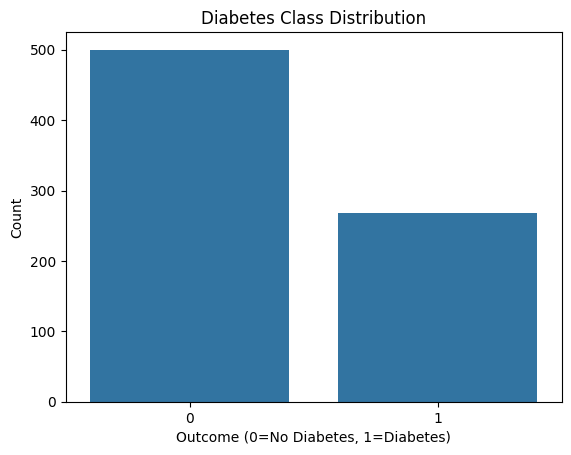

In [ ]:
print(df['Outcome'].value_counts())
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Class Distribution")
plt.xlabel("Outcome (0=No Diabetes, 1=Diabetes)")
plt.ylabel("Count")
plt.show()

In [ ]:
cols_with_zeros=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[cols_with_zeros]=df[cols_with_zeros].replace(0,np.nan)
df[cols_with_zeros]=df[cols_with_zeros].fillna(df[cols_with_zeros].median())

In [ ]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']

In [ ]:
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=0)

In [ ]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (614, 8)
Test size: (154, 8)


In [ ]:
models={
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Bagging Classifier": BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=100,random_state=0),
    "Random Forest": RandomForestClassifier(n_estimators=100,random_state=0)
       }

In [ ]:
results=[]
for name, model in models.items():
    model.fit(X_train, y_train)
    pred=model.predict(X_test)
    acc=accuracy_score(y_test,pred)
    pre=precision_score(y_test,pred)
    rec=recall_score(y_test,pred)
    f1=f1_score(y_test,pred)
    auc=roc_auc_score(y_test,pred)
    results.append([name,acc,pre,rec,f1,auc])

In [ ]:
results_df = pd.DataFrame(results,columns=["Model","Accuracy","Precision","Recall","F1","ROC_AUC"])
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Decision Tree,0.701299,0.510638,0.510638,0.510638,0.647843
1,Bagging Classifier,0.805195,0.673469,0.702128,0.687500,0.776297
2,Random Forest,0.818182,0.702128,0.702128,0.702128,0.785643


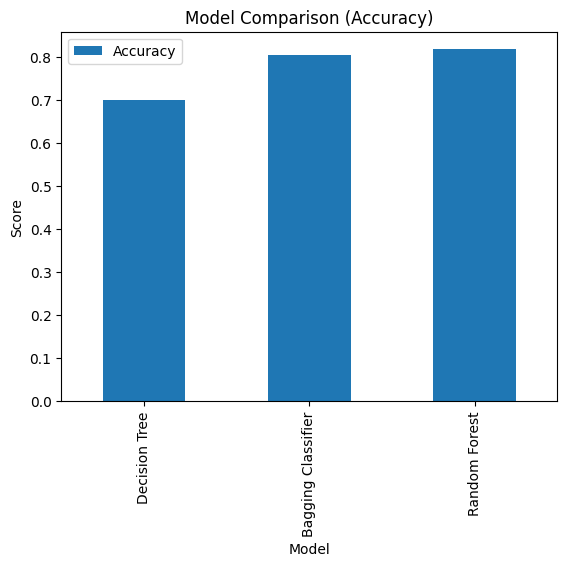

In [ ]:
results_df.plot(x="Model",y="Accuracy",kind="bar")
plt.title("Model Comparison (Accuracy)")
plt.ylabel("Score")
plt.show()

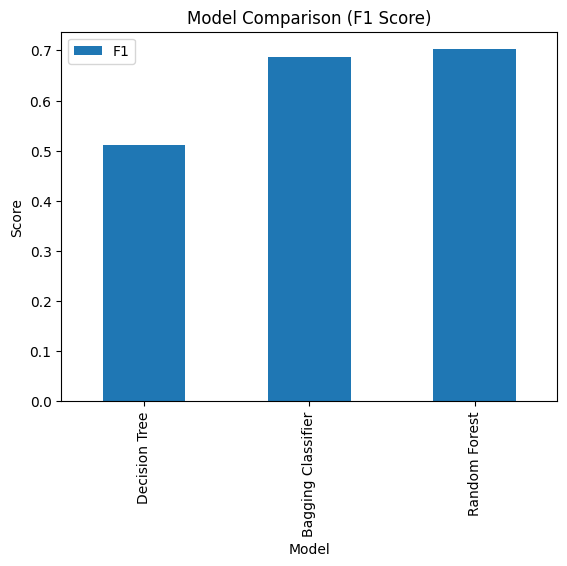

In [ ]:
results_df.plot(x="Model",y="F1",kind="bar")
plt.title("Model Comparison (F1 Score)")
plt.ylabel("Score")
plt.show()

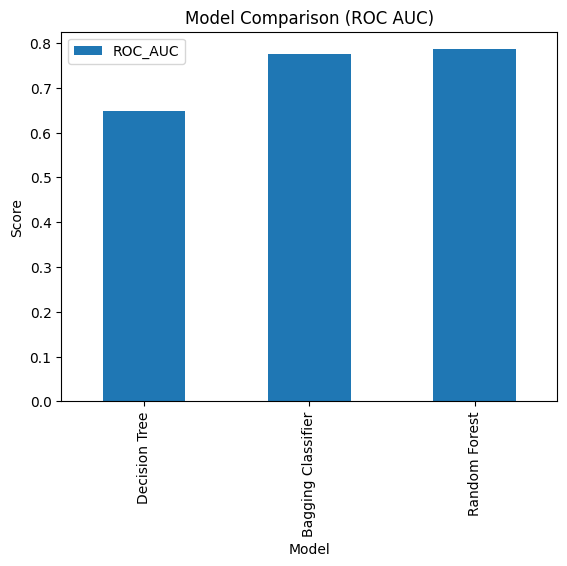

In [ ]:
results_df.plot(x="Model",y="ROC_AUC",kind="bar")
plt.title("Model Comparison (ROC AUC)")
plt.ylabel("Score")
plt.show()

In [ ]:
best_name=results_df.sort_values("F1",ascending=False).iloc[0,0]
best_model=models[best_name]
print("Best Model:",best_name)

Best Model: Random Forest


In [ ]:
with open("diabetes_best_model.pkl","wb") as f:
    pickle.dump(best_model,f)

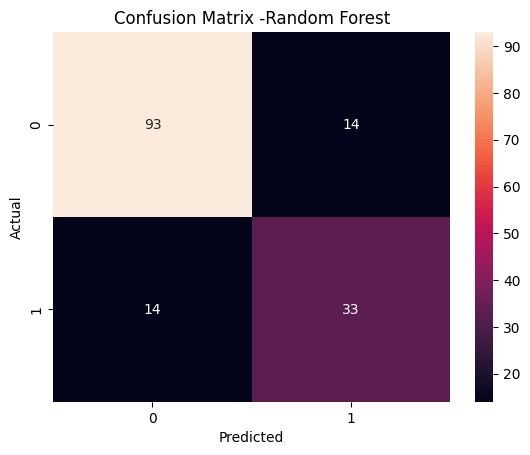

In [ ]:
pred=best_model.predict(X_test)
cm=confusion_matrix(y_test,pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title("Confusion Matrix -"+best_name)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print(classification_report(y_test,pred))


              precision    recall  f1-score   support

           0       0.87      0.87      0.87       107
           1       0.70      0.70      0.70        47

    accuracy                           0.82       154
   macro avg       0.79      0.79      0.79       154
weighted avg       0.82      0.82      0.82       154

